In [ ]:
import numpy as np 
import pandas as pd 

/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e7/train.csv
/kaggle/input/competitions/playground-series-s6e7/test.csv


In [ ]:
train = pd.read_csv("playground-series-s6e7/train.csv")
test = pd.read_csv("playground-series-s6e7/test.csv")

In [211]:
train.tail()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
690083,690083,at-risk,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female
690084,690084,at-risk,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male
690085,690085,fit,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male
690086,690086,at-risk,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male
690087,690087,at-risk,5.55,69.3,24.38,2257.0,5144.0,47.9,1.76,balanced,medium,average,moderate,yes,male


In [212]:
test.head()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,690088,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,690089,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,690090,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,690091,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,690092,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other


In [213]:
print(train.shape)
print(test.shape)

(690088, 15)
(295753, 14)


In [214]:
df = pd.concat([train,test], axis=0)

In [215]:
df.shape

(985841, 15)

In [216]:
df.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [217]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 985841 entries, 0 to 295752
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       985841 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           877271 non-null  float64
 3   heart_rate               974651 non-null  float64
 4   bmi                      965987 non-null  float64
 5   calorie_expenditure      910336 non-null  float64
 6   step_count               965961 non-null  float64
 7   exercise_duration        975982 non-null  float64
 8   water_intake             923731 non-null  float64
 9   diet_type                975982 non-null  object 
 10  stress_level             867540 non-null  object 
 11  sleep_quality            902511 non-null  object 
 12  physical_activity_level  933525 non-null  object 
 13  smoking_alcohol          945010 non-null  object 
 14  gender   

In [218]:
df = df.reset_index(drop=True)

In [220]:
stud_ids = test['id'].copy()

In [221]:
stud_ids.head()

0    690088
1    690089
2    690090
3    690091
4    690092
Name: id, dtype: int64

In [222]:
for col in df.select_dtypes(include=['object']).columns:
    print(col, df[col].nunique())

health_condition 3
diet_type 3
stress_level 3
sleep_quality 3
physical_activity_level 3
smoking_alcohol 3
gender 3


In [223]:
df.drop(columns='id',inplace=True)

In [224]:
df.columns

Index(['health_condition', 'sleep_duration', 'heart_rate', 'bmi',
       'calorie_expenditure', 'step_count', 'exercise_duration',
       'water_intake', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender'],
      dtype='object')

In [225]:
df.isnull().sum()

health_condition           295753
sleep_duration             108570
heart_rate                  11190
bmi                         19854
calorie_expenditure         75505
step_count                  19880
exercise_duration            9859
water_intake                62110
diet_type                    9859
stress_level               118301
sleep_quality               83330
physical_activity_level     52316
smoking_alcohol             40831
gender                      30533
dtype: int64

In [226]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: ylabel='sleep_duration'>

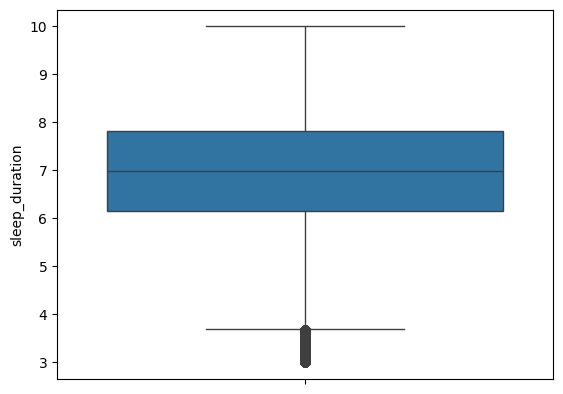

In [227]:
sns.boxplot(df['sleep_duration'])

In [228]:
Q1 = df['sleep_duration'].quantile(0.25)
Q3 = df['sleep_duration'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Limit:", lower)
print("Upper Limit:", upper)

outliers = df[(df['sleep_duration'] < lower) | (df['sleep_duration'] > upper)]
outliers

Lower Limit: 3.685000000000001
Upper Limit: 10.284999999999998


,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
297,unhealthy,3.65,72.2,21.84,2078.0,10897.0,48.8,2.12,veg,high,NaN,NaN,NaN,male
385,at-risk,3.40,73.5,24.32,1925.0,11926.0,35.7,2.61,balanced,low,poor,moderate,no,other
441,unhealthy,3.09,71.2,23.02,2052.0,7346.0,31.9,NaN,veg,high,poor,sedentary,occasional,female
465,at-risk,3.53,80.6,25.22,2747.0,11353.0,65.6,1.70,non-veg,low,average,active,occasional,female
684,unhealthy,3.53,85.0,21.86,1439.0,5557.0,0.4,2.77,veg,high,average,sedentary,occasional,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
984522,NaN,3.11,75.9,21.44,1603.0,9461.0,34.2,2.76,non-veg,medium,poor,sedentary,occasional,male
984752,NaN,3.45,80.4,28.59,2071.0,3921.0,52.2,0.94,veg,high,poor,moderate,no,female
984764,NaN,3.03,83.4,19.93,2202.0,1878.0,25.2,1.21,non-veg,low,poor,sedentary,occasional,female
985080,NaN,3.66,76.5,24.11,2254.0,13897.0,44.1,3.53,balanced,high,NaN,active,no,female


In [229]:
df[['stress_level','smoking_alcohol']]

,stress_level,smoking_alcohol
0,high,yes
1,low,yes
2,high,yes
3,high,occasional
4,NaN,NaN
...,...,...
985836,low,occasional
985837,NaN,yes
985838,high,no
985839,high,no


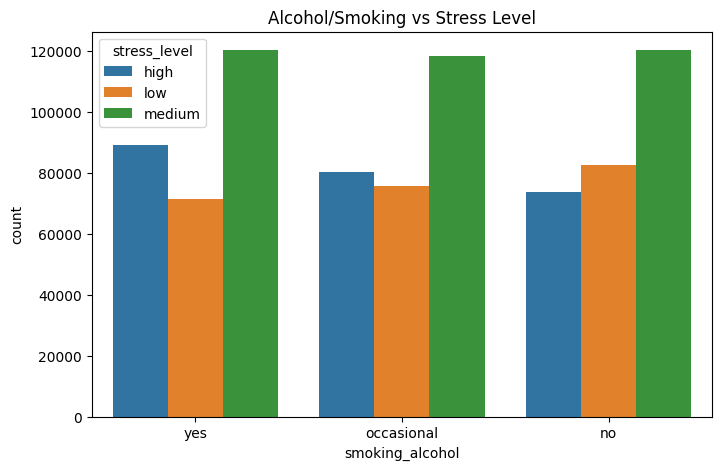

In [230]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='smoking_alcohol', hue='stress_level')

plt.title("Alcohol/Smoking vs Stress Level")
plt.show()

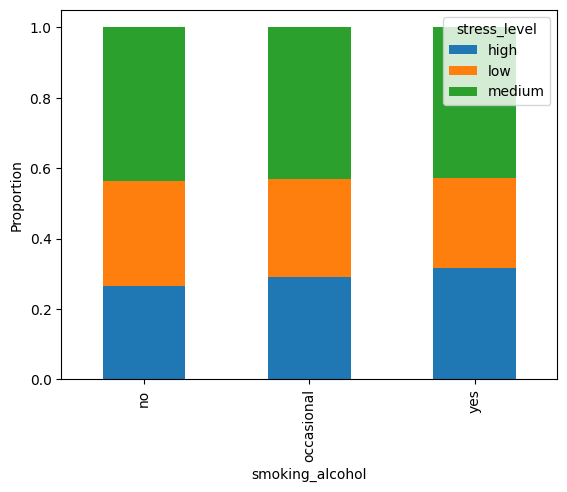

In [231]:
ct = pd.crosstab(
    df['smoking_alcohol'],
    df['stress_level'],
    normalize='index'
)

ct.plot(kind='bar', stacked=True)
plt.ylabel("Proportion")
plt.show()

No relation between smoking_alcohol and stress_level🥀

## New Features

In [232]:
df.columns

Index(['health_condition', 'sleep_duration', 'heart_rate', 'bmi',
       'calorie_expenditure', 'step_count', 'exercise_duration',
       'water_intake', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender'],
      dtype='object')

In [233]:
df["activity_score"] = (
    df["step_count"] * df["exercise_duration"]
)
## higher value will indicate healthy student

In [234]:
df["recovery_score"] = (
    df["sleep_duration"] *
    df["water_intake"]
)

In [235]:
df["bmi_heart"] = (
    df["bmi"] *
    df["heart_rate"]
)

## filling nulls and encoding

In [236]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols = [col for col in cat_cols if col != "health_condition"]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
for col in cat_cols:  
    df[col] = df[col].fillna('unknown')

In [237]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"\n{col}:")
    print(mapping)


diet_type:
{'balanced': np.int64(0), 'non-veg': np.int64(1), 'unknown': np.int64(2), 'veg': np.int64(3)}

stress_level:
{'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2), 'unknown': np.int64(3)}

sleep_quality:
{'average': np.int64(0), 'good': np.int64(1), 'poor': np.int64(2), 'unknown': np.int64(3)}

physical_activity_level:
{'active': np.int64(0), 'moderate': np.int64(1), 'sedentary': np.int64(2), 'unknown': np.int64(3)}

smoking_alcohol:
{'no': np.int64(0), 'occasional': np.int64(1), 'unknown': np.int64(2), 'yes': np.int64(3)}

gender:
{'female': np.int64(0), 'male': np.int64(1), 'other': np.int64(2), 'unknown': np.int64(3)}


In [238]:
df.head()

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,activity_score,recovery_score,bmi_heart
0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,3,0,0,2,3,0,26254.8,9.7092,1811.596
1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,1,1,0,1,3,2,493560.9,6.9678,1842.392
2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,3,0,2,0,3,1,541629.6,8.4640,1850.316
3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,3,0,0,0,1,0,429722.6,9.4940,1785.636
4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,3,3,0,2,2,1,302864.0,16.2675,2087.496


## new features for cat_cols

In [239]:
df["stress_smoking"] = (
    df["stress_level"] *
    df["smoking_alcohol"]
)

In [240]:
df["healthy_lifestyle"] = (
    df["diet_type"] *
    df["physical_activity_level"]
)

In [241]:
df["stress_sleep"] = df["stress_level"] * df["sleep_duration"]

In [242]:
df["diet_water"] = (
    df["diet_type"] *
    df["water_intake"]
)

some extra features using MI scores

In [243]:
df["stress_sleep_quality"] = df["stress_level"] * df["sleep_quality"]

df["activity_sleep"] = df["physical_activity_level"] * df["sleep_duration"]

df["diet_sleep"] = df["diet_type"] * df["sleep_quality"]

df["stress_diet"] = df["stress_level"] * df["diet_type"]

df["stress_activity_sleep"] = (
    df["stress_level"] *
    df["physical_activity_level"] *
    df["sleep_duration"]
)

In [244]:
df.shape

(985841, 26)

## LightBGM

In [245]:
train_df = df[df["health_condition"].notna()].copy()
test_df = df[df["health_condition"].isna()].copy()

In [247]:
test_df

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,...,bmi_heart,stress_smoking,healthy_lifestyle,stress_sleep,diet_water,stress_sleep_quality,activity_sleep,diet_sleep,stress_diet,stress_activity_sleep
690088,NaN,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,3,0,...,1523.852,0,0,0.00,5.58,0,0.00,6,0,0.00
690089,NaN,6.99,83.1,22.42,1773.0,6801.0,24.5,2.40,0,0,...,1863.102,0,0,0.00,0.00,0,13.98,0,0,0.00
690090,NaN,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,0,2,...,1441.158,0,0,13.36,0.00,4,0.00,0,0,0.00
690091,NaN,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,3,1,...,2061.410,3,3,7.13,7.02,1,7.13,3,3,7.13
690092,NaN,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,3,0,...,1809.633,0,0,0.00,7.35,0,0.00,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
985836,NaN,7.13,77.5,22.20,2221.0,13981.0,65.6,2.17,0,1,...,1720.500,1,0,7.13,0.00,0,0.00,0,0,0.00
985837,NaN,6.25,69.5,20.93,2242.0,2370.0,23.6,1.98,0,3,...,1454.635,9,0,18.75,0.00,0,6.25,0,0,18.75
985838,NaN,6.99,77.0,23.62,2111.0,7647.0,25.1,2.18,3,0,...,1818.740,0,6,0.00,6.54,0,13.98,0,0,0.00
985839,NaN,7.25,66.3,21.47,2009.0,4672.0,25.1,2.02,3,0,...,1423.461,0,3,0.00,6.06,0,7.25,6,0,0.00


In [249]:
X_train = train_df.drop("health_condition", axis=1)
y_train = train_df["health_condition"]

X_test = test_df.drop("health_condition", axis=1)

In [251]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    objective="multiclass",
    num_class=3,
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [252]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

model.fit(X_tr, y_tr)

val_pred = model.predict(X_val)

print("Balanced Accuracy:",
      balanced_accuracy_score(y_val, val_pred))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.097901 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3629
[LightGBM] [Info] Number of data points in the train set: 552070, number of used features: 25
[LightGBM] [Info] Start training from score -0.152364
[LightGBM] [Info] Start training from score -2.852889
[LightGBM] [Info] Start training from score -2.481150
Balanced Accuracy: 0.87850385902295


In [253]:
pred = model.predict(X_test)

In [256]:
submission = pd.DataFrame({
    "student_id": stud_ids,
    "health_condition": pred
})

In [257]:
submission.head()

,student_id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


In [ ]:
submission.to_csv("submission-3.csv", index=False)